# 로지스틱 회귀

## 데이터 준비

In [2]:
import pandas as pd

In [3]:
fish = pd.read_csv('fish_data.csv')

In [4]:
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [5]:
import numpy as np

In [42]:
# np.unique() 함수는 배열에서 고유한 값을 반환하는 함수입니다. 
# return_counts=True 매개변수를 사용하여 각 고유 값의 개수를 함께 반환합니다.
np.unique(fish['Species'], return_counts=True)

(array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
       dtype=object),
 array([35, 11, 56, 17, 20, 14,  6]))

In [7]:
fish.columns

Index(['Species', 'Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='str')

In [8]:
# fish 데이터에서 'Species' 열을 fish_target에 저장하고, 나머지 열을 fish_input에 저장합니다.
fish_target = fish['Species'].to_numpy()
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

In [9]:
print(fish_input.shape, fish_target.shape)

(159, 5) (159,)


In [10]:
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
# StandardScaler는 데이터의 평균을 0, 표준편차를 1로 변환하는 스케일링 방법입니다.
# fit() 메서드는 데이터를 사용하여 스케일링을 학습하는 메서드입니다. fish_input을 사용하여 스케일링을 학습합니다.
# transform() 메서드는 학습된 스케일링을 사용하여 데이터를 변환하는 메서드입니다. fish_input을 사용하여 데이터를 변환합니다.
ss = StandardScaler()
ss.fit(fish_input)
fish_scaled = ss.transform(fish_input)

In [13]:
print(fish_scaled)

[[-4.38072172e-01 -2.82303007e-01 -1.06020232e-01  5.96578670e-01
  -2.36528948e-01]
 [-3.03562184e-01 -1.98053663e-01 -2.33668373e-03  8.21260549e-01
  -6.65789457e-02]
 [-1.63447613e-01 -1.79331587e-01 -1.09769794e-02  7.97341291e-01
   1.65793169e-01]
 [-9.89949100e-02  5.46943678e-02  1.96390116e-01  8.79771455e-01
   2.26210031e-02]
 [ 8.87586153e-02  5.46943678e-02  2.39591594e-01  8.12834979e-01
   4.26371272e-01]
 [ 1.44804444e-01  1.20221635e-01  3.00073664e-01  1.08395111e+00
   3.03431249e-01]
 [ 2.84919015e-01  1.20221635e-01  2.82793073e-01  1.21901769e+00
   5.12357880e-01]
 [-2.33330416e-02  1.48304750e-01  3.25994551e-01  8.65728838e-01
   1.62163285e-01]
 [ 1.44804444e-01  1.48304750e-01  3.34634847e-01  1.17815367e+00
   2.53683979e-01]
 [ 2.84919015e-01  2.13832017e-01  4.29678099e-01  1.23004114e+00
   3.22473266e-01]
 [ 2.14861729e-01  2.41915132e-01  4.29678099e-01  1.23851352e+00
   4.08638393e-01]
 [ 2.84919015e-01  2.41915132e-01  4.29678099e-01  1.26393066e+00

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# train_test_split() 함수는 데이터를 학습용과 테스트용으로 나누는 함수입니다. 
# fish_scaled와 fish_target을 사용하여 데이터를 나눕니다. 
# random_state=11 매개변수는 데이터를 나누는 방법을 고정하는 매개변수입니다.
# text size 매개변수는 테스트 데이터의 비율을 지정하는 매개변수입니다. default 값은 0.25입니다.
train_input, test_input, train_target, test_target = \
      train_test_split(fish_scaled, 
                 fish_target, 
                 random_state=11)

In [43]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(119, 5) (119,)
(40, 5) (40,)


## 로지스틱 회귀


### $$ z = a \times weight + b \times length + c \times diagonal + d \times height + e \times width + f $$
### $$z= ax_0 + bx_1 + cx_2 + dx_3 + ex_4 + fx_5 + g $$ 

### $$z= w_0x_0 + w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + w_5x_5 + b $$


## Sigmoid
## $$ \theta = \frac {1}{ 1+e^{-z}} $$


In [29]:
import matplotlib.pyplot as plt

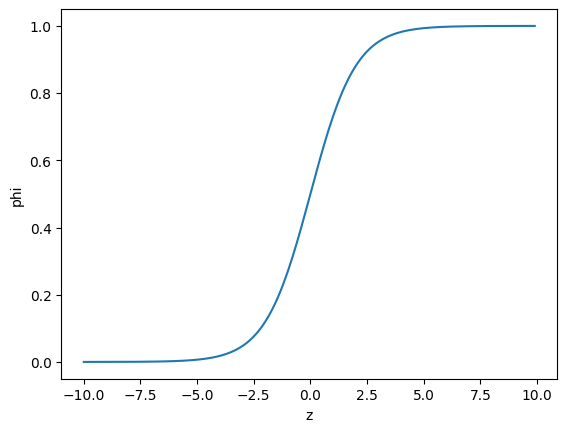

In [30]:
z =  np.arange(-10, 10, 0.1)
phi = 1/(1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()


# 로지스틱 회귀를 이용한 이진 분류

In [19]:
#불리언 인덱싱
char_arr = np.array(['A','B','C','D','E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [31]:
# 불리언 인덱싱을 사용하여 train_target에서 'Bream' 또는 'Smelt'인 데이터의 인덱스를 찾습니다.
bs_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
bs_indexes

array([False,  True, False, False, False, False, False, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True,  True,  True,  True, False, False, False,  True, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False,  True,  True, False,  True, False, False,
       False, False,  True,  True,  True, False, False, False,  True,
       False,  True, False, False, False, False, False, False, False,
        True,  True, False, False,  True, False,  True, False, False,
       False,  True, False, False,  True, False, False, False,  True,
        True, False, False, False, False,  True, False, False, False,
       False, False,  True, False, False, False,  True, False, False,
       False,  True])

In [32]:
# 불리언 인덱싱을 사용하여 train_input과 train_target에서 'Bream' 또는 'Smelt'인 데이터만 선택합니다.
train_bs = train_input[bs_indexes]
target_bs = train_target[bs_indexes]

In [44]:
print(train_bs.shape, target_bs.shape)

(32, 5) (32,)


In [25]:
from sklearn.linear_model import LogisticRegression

In [52]:
# LogisticRegression 클래스는 로지스틱 회귀 모델을 구현하는 클래스입니다.
# fit() 메서드는 데이터를 사용하여 모델을 학습하는 메서드입니다. 
# train_bs와 target_bs를 사용하여 모델을 학습합니다.
lr = LogisticRegression()
lr.fit(train_bs, target_bs)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
lr.predict(train_bs[:5])

array(['Bream', 'Bream', 'Bream', 'Bream', 'Smelt'], dtype=object)

In [48]:
target_bs[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Smelt'], dtype=object)

## 로지스틱 회귀 계수 확인

In [53]:
print(lr.coef_, lr.intercept_)

[[-0.41036912 -0.57228354 -0.64216513 -0.90299219 -0.73648258]] [-2.1861111]


## $$-{(y\log(p) + (1 - y)\log(1 - p))} $$


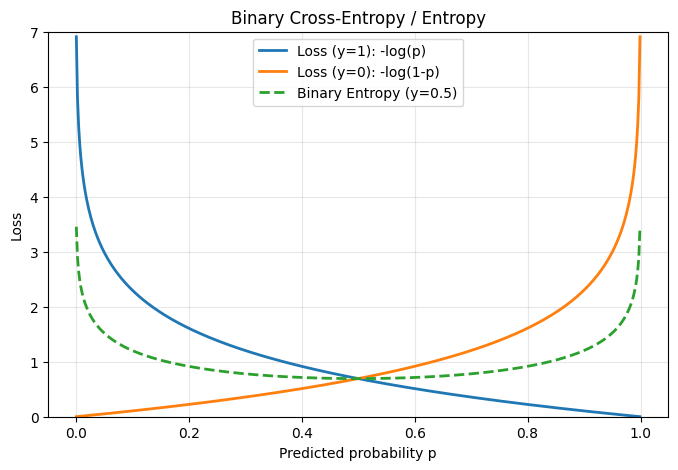

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# p=0,1에서 log가 발산하므로 아주 작은 epsilon으로 클리핑
p = np.linspace(0.001, 0.999, 500)

def binary_cross_entropy(y, p):
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

loss_y1 = binary_cross_entropy(1, p)   # y=1일 때
loss_y0 = binary_cross_entropy(0, p)   # y=0일 때
entropy = binary_cross_entropy(0.5, p) # 이진 엔트로피(H)

plt.figure(figsize=(8, 5))
plt.plot(p, loss_y1, label='Loss (y=1): -log(p)', linewidth=2)
plt.plot(p, loss_y0, label='Loss (y=0): -log(1-p)', linewidth=2)
plt.plot(p, entropy, '--', label='Binary Entropy (y=0.5)', linewidth=2)

plt.title('Binary Cross-Entropy / Entropy')
plt.xlabel('Predicted probability p')
plt.ylabel('Loss')
plt.ylim(0, 7)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 로지스틱 회귀로 다중 분류 수행하기


###  이진 분류기를 활용하여 다중 클래스 분류 가능
    * 일대다(OvR 또는 OvA)
    * 일대일(OvO)

### 일대다 방식 활용 예제
    * 숫자 5 예측하기에서 사용했던 이진 분류 방식을 동일하게 모든 숫자에 대해서 실행
    * 각 샘플에 대해 총 10번 각기 다른 이진 분류기를 실행
    * 이후 각 분류기의 결정 점수 중에서 가장 높은 점수를 받은 클래스를 해당 샘플의 클래스로 선택

### 일대일 방식 활용 예제
    * 조합 가능한 모든 클래스 일대일 분류 방식을 진행하여 가장 많은 결투(duell)를 이긴 숫자를 선택
    * MNIST의 경우, 0과 1 구별, 0과 2 구별, ..., 1과 2 구별, 1과 3 구별, ..., 8과 9 구별 등 
        (9+8+...+1 = 45)개의 결투를 판별하는 45개의 분류기 활용.
        단, 각 결투에 해당되는 데이터 샘플만 훈련에 사용됨.
    * 각각의 훈련 샘플에 대해 가장 많은 결투를 이긴 숫자의 클래스를 예측값으로 사용함.
        예를 들어, 숫자 1이 9번의 결투를 모두 이기면 숫자 1을 예측값으로 지정함.

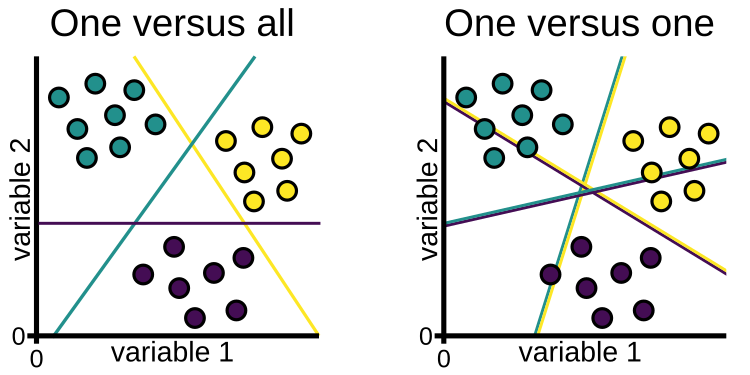

In [46]:
# c=1, max_iter=1000 매개변수는 모델의 복잡도와 학습 반복 횟수를 조절하는 매개변수입니다.
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_input, train_target)
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))


0.9411764705882353
0.9


In [49]:
lr.predict(test_input[:5])

array(['Smelt', 'Perch', 'Bream', 'Perch', 'Perch'], dtype=object)

In [50]:
test_target[:5]

array(['Smelt', 'Smelt', 'Bream', 'Perch', 'Perch'], dtype=object)

In [51]:
proba = lr.predict_proba(test_input[:5])
print(np.round(proba, decimals=2))

[[0.   0.   0.12 0.   0.02 0.86 0.  ]
 [0.   0.01 0.47 0.   0.09 0.43 0.  ]
 [0.98 0.01 0.   0.   0.   0.   0.01]
 [0.   0.03 0.62 0.   0.12 0.23 0.01]
 [0.   0.   0.93 0.   0.05 0.   0.02]]
